<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/PRACTICA_AST_Clase_7_2_PyCaret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 7 - Introducción a PyCaret</h3>
    <h3>Ejercicio 2</h3>
        <p>Docentes: Calcagno Sebastian , Rodrigo Del Rosso, Drago B.<p>
</div>

# PyCaret Time Series Forecasting

Origen de la info: https://pycaret.gitbook.io/docs/get-started/quickstart

PyCaret es una biblioteca de código abierto en Python que permite automatizar flujos de trabajo de machine learning con poco código. Es una herramienta integral que acelera drásticamente los ciclos de experimentación y mejora la productividad.

A diferencia de otras bibliotecas de machine learning en Python, PyCaret permite reemplazar cientos de líneas de código con solo unas pocas, lo que hace que los experimentos sean mucho más rápidos y eficientes. Actúa como un envoltorio (wrapper) en Python que integra múltiples bibliotecas y frameworks como scikit-learn, XGBoost, LightGBM, CatBoost, spaCy, Optuna, Hyperopt, Ray, entre otros.


# Instalacion



In [ ]:
pip install pycaret[time_series]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 35.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done


In [ ]:
#pip install pycaret[full]

In [ ]:
#pip install pycaret[analysis]
#pip install pycaret[models]
#pip install pycaret[tuner]
#pip install pycaret[mlops]
#pip install pycaret[parallel]
#pip install pycaret[test]

In [ ]:
# check installed version
import pycaret
pycaret.__version__

'3.3.2'

# Comienzo

El flujo de trabajo típico en PyCaret para series temporales sigue estos 5 pasos:

Carga de datos y configuración del entorno (setup)

Comparación de modelos automáticamente (compare_models)

Creación de modelos (create_model)

Evaluación de modelos (evaluate_model)

Predicción, afinación, ensamblado y despliegue (predict_model, tune_model, blend_models, deploy_model, etc.)



In [ ]:
# Ver todos los datasets disponibles
available_datasets = get_data('index')

# Mostrar los primeros
print(available_datasets.head())

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


   Dataset    Data Types             Default Task Target Variable 1  \
0  anomaly  Multivariate        Anomaly Detection               NaN   
1   france  Multivariate  Association Rule Mining         InvoiceNo   
2  germany  Multivariate  Association Rule Mining         InvoiceNo   
3     bank  Multivariate  Classification (Binary)           deposit   
4    blood  Multivariate  Classification (Binary)             Class   

  Target Variable 2  # Instances  # Attributes Missing Values  
0               NaN         1000            10              N  
1       Description         8557             8              N  
2       Description         9495             8              N  
3               NaN        45211            17              N  
4               NaN          748             5              N  


In [ ]:
### loading sample dataset from pycaret dataset module
from pycaret.datasets import get_data
data = get_data('airline')

,Number of airline passengers
Period,
1949-01,112.0
1949-02,118.0
1949-03,132.0
1949-04,129.0
1949-05,121.0


<Axes: xlabel='Period'>

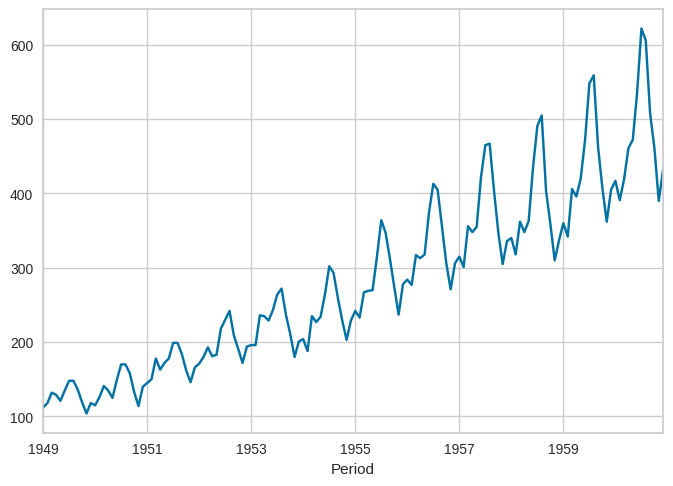

In [ ]:
# plot the dataset
data.plot()

## Setup
La función setup inicializa el entorno de entrenamiento y crea el pipeline de transformaciones. Es obligatorio llamarla antes de ejecutar cualquier otra función de PyCaret.

Setup tiene un solo parametro obligatorio q es data.

fh = 3: forecast horizon, es decir, el número de pasos hacia adelante que se quiere predecir (en este caso, 3 períodos).

In [ ]:
# import pycaret time series and init setup
from pycaret.time_series import *
s = setup(data, fh = 3, session_id = 123)

,Description,Value
0,session_id,123
1,Target,Number of airline passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(144, 1)"
5,Transformed data shape,"(144, 1)"
6,Transformed train set shape,"(141, 1)"
7,Transformed test set shape,"(3, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


Una vez que se ejecuta correctamente la función setup, PyCaret muestra una cuadrícula de información con los detalles del experimento. Los campos principales incluyen:

Session id: Número pseudoaleatorio usado como semilla para asegurar la reproducibilidad. Si no se especifica, se genera automáticamente.

Approach (Enfoque): Indica si el problema es univariado o multivariado.

Exogenous Variables (Variables exógenas): Variables adicionales externas que se usarán como entrada para el modelo (por ejemplo, factores que influyen en la serie pero no son parte directa de ella).

Original data shape: Dimensiones del conjunto de datos original antes de cualquier transformación.

Transformed train set shape: Dimensiones del conjunto de entrenamiento luego del preprocesamiento.

Transformed test set shape: Dimensiones del conjunto de prueba luego del preprocesamiento.

**PyCaret ofrece dos formas de trabajar:**

con funciones sueltas como:  
setup(...)  
compare_models()  
create_model()  

**API Orientada a Objetos (Object-Oriented API)**  
En esta modalidad, en lugar de usar funciones globales, se importa una clase y se crean instancias sobre las que se llaman métodos.  

Más control sobre el flujo de trabajo

Permite manejar varios experimentos en paralelo (algo que no podés hacer con la API funcional)

"TSForecastingExperiment crea un entorno de trabajo para series temporales. En exp vamos a guardar nuestro experimento y desde ahi vamos a configurar los datos, entrenar modelos, compararlos y hacer pronosticos."

In [ ]:
# import TSForecastingExperiment and init the class
from pycaret.time_series import TSForecastingExperiment
exp = TSForecastingExperiment()

In [ ]:
# check the type of exp
type(exp)

pycaret.time_series.forecasting.oop.TSForecastingExperiment

Comentario: se pueden incluir folds para los entrenamamientos, asi como tambien la target (ejemplo la feature "Close" para cotizaciones)

In [ ]:
# Crear el experimento con setup
exp.setup(data, fh = 3, session_id = 123)

,Description,Value
0,session_id,123
1,Target,Number of airline passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(144, 1)"
5,Transformed data shape,"(144, 1)"
6,Transformed train set shape,"(141, 1)"
7,Transformed test set shape,"(3, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


## Check Stats
La fc se usa para obtener estadísticas descriptivas y ejecutar tests estadísticos sobre los datos originales (serie temporal)

In [ ]:
# Comprobar las pruebas estadísticas sobre los datos originales.
check_stats()

,Test,Test Name,Data,Property,Setting,Value
0,Summary,Statistics,Transformed,Length,,144.0
1,Summary,Statistics,Transformed,# Missing Values,,0.0
2,Summary,Statistics,Transformed,Mean,,280.298611
3,Summary,Statistics,Transformed,Median,,265.5
4,Summary,Statistics,Transformed,Standard Deviation,,119.966317
5,Summary,Statistics,Transformed,Variance,,14391.917201
6,Summary,Statistics,Transformed,Kurtosis,,-0.364942
7,Summary,Statistics,Transformed,Skewness,,0.58316
8,Summary,Statistics,Transformed,# Distinct Values,,118.0
9,White Noise,Ljung-Box,Transformed,Test Statictic,"{'alpha': 0.05, 'K': 24}",1606.083817


## Compare Models

La función entrena y evalúa automáticamente todos los modelos disponibles en la librería de PyCaret utilizando validación cruzada (CV).

Las métricas evaluadas (por ejemplo MAE, RMSE, MAPE) se pueden:

Consultar con get_metrics()

Personalizar con add_metric() o remove_metric()

In [ ]:
# comparar modelos de referencia
best = compare_models()

#modelo ganador relacionado con la presencia de estaconalidad

#dataset tiene estacionalidad, tiene sentido

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
stlf,STLF,0.4136,0.4530,12.7373,15.8272,0.0262,0.0261,0.2016,0.0733
ets,ETS,0.4912,0.5541,15.0940,19.3099,0.0318,0.0316,-0.4465,0.1633
exp_smooth,Exponential Smoothing,0.4929,0.5561,15.1478,19.3792,0.0320,0.0317,-0.4605,2.3567
arima,ARIMA,0.6964,0.7110,21.3757,24.7774,0.0447,0.0456,-0.5495,0.1733
auto_arima,Auto ARIMA,0.7136,0.6945,21.9390,24.2138,0.0459,0.0464,-0.5454,30.7667
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.8658,0.8362,26.7826,29.3947,0.0516,0.0536,0.1501,0.1867
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.8904,0.8722,27.5266,30.6243,0.0534,0.0555,-0.0092,0.6467
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.8905,0.8722,27.5270,30.6246,0.0534,0.0555,-0.0092,0.2500
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.8944,0.8746,27.6535,30.7127,0.0535,0.0557,-0.0063,0.3300
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.8966,0.8759,27.7231,30.7594,0.0536,0.0558,-0.0040,0.1800


Processing:   0%|          | 0/117 [00:00<?, ?it/s]

## Analyze Model

La función plot_model() se utiliza para analizar visualmente el desempeño de un modelo entrenado, aplicándolo sobre el conjunto de test.  

Según el tipo de gráfico (plot=), puede mostrar:

'forecast': comparación entre predicciones y valores reales

'residuals': análisis gráfico de los errores

'acf' y 'pacf': autocorrelación de los residuos

'diagnostics': resumen de métricas y comportamiento del modelo

In [ ]:
# plot forecast
plot_model(best, plot = 'forecast')

In [ ]:
# plot forecast for 36 months in future
plot_model(best, plot = 'forecast', data_kwargs = {'fh' : 36})

In [ ]:
# residuals plot
plot_model(best, plot = 'residuals')

In [ ]:
plot_model(best, plot = 'acf')

In [ ]:
plot_model(best, plot = 'diagnostics')

## Prediction
La fc devuelve las predicciones (y_pred) del modelo entrenado.  

Si no se le pasa ningún data (es decir, data=None):

Utiliza automáticamente el horizonte de predicción (fh) definido durante el setup().

Esto significa que predice hacia adelante según la cantidad de pasos que se configuró (por ejemplo, 3 pasos si se utilizó fh=3).

In [ ]:
# predecir en el conjunto de prueba
holdout_pred = predict_model(best)

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,STLF,0.3305,0.3157,10.5518,11.4475,0.0255,0.0252,0.8457


In [ ]:
# mostrar predicciones df
holdout_pred.head()

,y_pred
1960-10,455.2909
1960-11,406.4324
1960-12,441.5140


In [ ]:
# Generar pronóstico para 36 períodos en el futuro
predict_model(best, fh = 36)

,y_pred
1960-10,455.2909
1960-11,406.4324
1960-12,441.5140
1961-01,456.2386
1961-02,430.1439
1961-03,471.7323
1961-04,490.5395
1961-05,507.2320
1961-06,567.3178
1961-07,650.9920


## Save Model

La fc permite guardar en disco todo el pipeline del modelo, incluyendo:  

El modelo entrenado

Las transformaciones aplicadas (preprocesamiento, creación de lags, etc.)

Todos los parámetros y configuraciones del experimento

In [ ]:
# guarda el pipeline
save_model(best, 'my_first_pipeline')

Transformation Pipeline and Model Successfully Saved


(ForecastingPipeline(steps=[('forecaster',
                             TransformedTargetForecaster(steps=[('model',
                                                                 STLForecaster(sp=12))]))]),
 'my_first_pipeline.pkl')

In [ ]:
# descarga pipeline
loaded_best_pipeline = load_model('my_first_pipeline')
loaded_best_pipeline

Transformation Pipeline and Model Successfully Loaded


ForecastingPipeline(steps=[('forecaster',
                            TransformedTargetForecaster(steps=[('model',
                                                                STLForecaster(sp=12))]))])

##  Create Model
La fc esta se utiliza para entrenar y evaluar un modelo específico en un experimento de series temporales, usando validación cruzada.  

Entrena un modelo que el usuarioe elija:

Evalúa su desempeño usando la estrategia de cross-validation definida en setup() (por defecto expanding)

Devuelve una tabla de resultados por fold (scoring grid)

| Estrategia    | ¿Cómo valida?                                    |
| ------------- | ------------------------------------------------ |
| `'expanding'` | Aumenta progresivamente el set de entrenamiento  |
| `'rolling'`   | Usa ventanas deslizantes de entrenamiento y test |


In [ ]:
# chechea los modelos disponibles
models()

,Name,Reference,Turbo
ID,,,
naive,Naive Forecaster,sktime.forecasting.naive.NaiveForecaster,True
grand_means,Grand Means Forecaster,sktime.forecasting.naive.NaiveForecaster,True
snaive,Seasonal Naive Forecaster,sktime.forecasting.naive.NaiveForecaster,True
polytrend,Polynomial Trend Forecaster,sktime.forecasting.trend._polynomial_trend_for...,True
arima,ARIMA,sktime.forecasting.arima.ARIMA,True
auto_arima,Auto ARIMA,sktime.forecasting.arima.AutoARIMA,True
exp_smooth,Exponential Smoothing,sktime.forecasting.exp_smoothing.ExponentialSm...,True
ets,ETS,sktime.forecasting.ets.AutoETS,True
theta,Theta Forecaster,sktime.forecasting.theta.ThetaForecaster,True


Exponential Smoothing

In [ ]:
# Entrenar ets con fold=3 por defecto
ets = create_model('ets')

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.5083,0.7238,15.4772,25.0045,0.0371,0.0354,-2.8436
1,1960-03,0.6856,0.6262,21.0315,21.7984,0.0437,0.0448,0.5529
2,1960-06,0.2796,0.3123,8.7733,11.1270,0.0147,0.0146,0.9512
Mean,NaT,0.4912,0.5541,15.0940,19.3099,0.0318,0.0316,-0.4465
SD,NaT,0.1662,0.1755,5.0117,5.9324,0.0124,0.0126,1.7028


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

La función anterior devuelve un objeto modelo entrenado como resultado. La cuadrícula de puntuación solo se muestra y no se devuelve. Si necesita acceder a la cuadrícula de puntuación, puede usar la función pull para acceder al dataframe.

In [ ]:
ets_results = pull()
print(type(ets_results))
ets_results

<class 'pandas.core.frame.DataFrame'>


,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.5083,0.7238,15.4772,25.0045,0.0371,0.0354,-2.8436
1,1960-03,0.6856,0.6262,21.0315,21.7984,0.0437,0.0448,0.5529
2,1960-06,0.2796,0.3123,8.7733,11.1270,0.0147,0.0146,0.9512
Mean,NaT,0.4912,0.5541,15.0940,19.3099,0.0318,0.0316,-0.4465
SD,NaT,0.1662,0.1755,5.0117,5.9324,0.0124,0.0126,1.7028


In [ ]:
model = exp.create_model('lightgbm_cds_dt', fold=5)
results = exp.pull()
results.head()

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-06,1.7585,1.6340,51.1519,53.8785,0.0956,0.1008,-0.5775
1,1959-09,0.3403,0.4774,10.1399,16.1322,0.0252,0.0261,0.3960
2,1959-12,0.5100,0.4791,15.5302,16.5507,0.0380,0.0387,-0.6840
3,1960-03,1.3552,1.1946,41.5693,41.5835,0.0854,0.0893,-0.6269
4,1960-06,1.7406,1.7349,54.6082,61.8141,0.0905,0.0959,-0.5046
Mean,NaT,1.1409,1.1040,34.5999,37.9918,0.0670,0.0701,-0.3994
SD,NaT,0.6043,0.5423,18.3566,18.8168,0.0293,0.0313,0.4020


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-06,1.7585,1.6340,51.1519,53.8785,0.0956,0.1008,-0.5775
1,1959-09,0.3403,0.4774,10.1399,16.1322,0.0252,0.0261,0.3960
2,1959-12,0.5100,0.4791,15.5302,16.5507,0.0380,0.0387,-0.6840
3,1960-03,1.3552,1.1946,41.5693,41.5835,0.0854,0.0893,-0.6269
4,1960-06,1.7406,1.7349,54.6082,61.8141,0.0905,0.0959,-0.5046


In [ ]:
# ajustar los hiperparámetros de dt
tuned_dt = tune_model(model)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.5407,0.6045,16.4639,20.8849,0.0394,0.0388,-1.6814
1,1960-03,1.2104,1.0751,37.1273,37.4240,0.0757,0.0787,-0.3177
2,1960-06,1.1063,1.0898,34.7078,38.8293,0.0578,0.0599,0.4063
Mean,NaT,0.9524,0.9231,29.4330,32.3794,0.0576,0.0591,-0.5309
SD,NaT,0.2942,0.2254,9.2236,8.1480,0.0148,0.0163,0.8656


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    8.8s finished


La métrica a optimizar se puede definir en el parámetro optimize (valor predeterminado = 'MASE'). Además, se puede pasar una cuadrícula personalizada mediante el parámetro custom_grid.

In [ ]:
tuned_dt

BaseCdsDtForecaster(degree=7, deseasonal_model='multiplicative',
                    fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                        10, 9,
                                                                        8, 7, 6,
                                                                        5, 4, 3,
                                                                        2, 1]},
                                                   n_jobs=1)],
                    regressor=LGBMRegressor(bagging_freq=3, colsample_bytree=0.5,
              learning_rate=4.559379744551025e-06, max_depth=5,
              min_child_samples=76, n_estimators=139, n_jobs=-1, num_leaves=45,
              random_state=123, reg_alpha=2.8210427307018964e-05,
              reg_lambda=3.640786648416928e-08, subsample=0.5),
                    sp=12, window_length=20)

In [ ]:
# definir la cuadrícula de ajuste
dt_grid = {'regressor__max_depth' : [None, 2, 4, 6, 8, 10, 12]}

# Ajustar el modelo con cuadrícula y métrica personalizadas = MAE
tuned_dt = tune_model(tuned_dt, custom_grid = dt_grid, optimize = 'MAE')

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.5407,0.6045,16.4639,20.8849,0.0394,0.0388,-1.6814
1,1960-03,1.2104,1.0751,37.1273,37.4240,0.0757,0.0787,-0.3177
2,1960-06,1.1063,1.0898,34.7078,38.8293,0.0578,0.0599,0.4063
Mean,NaT,0.9524,0.9231,29.4330,32.3794,0.0576,0.0591,-0.5309
SD,NaT,0.2942,0.2254,9.2236,8.1480,0.0148,0.0163,0.8656


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 3 folds for each of 7 candidates, totalling 21 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  21 out of  21 | elapsed:    7.2s finished


In [ ]:
# ver parametros
tuned_dt

BaseCdsDtForecaster(degree=7, deseasonal_model='multiplicative',
                    fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                        10, 9,
                                                                        8, 7, 6,
                                                                        5, 4, 3,
                                                                        2, 1]},
                                                   n_jobs=1)],
                    regressor=LGBMRegressor(bagging_freq=3, colsample_bytree=0.5,
              learning_rate=4.559379744551025e-06, max_depth=5,
              min_child_samples=76, n_estimators=139, n_jobs=-1, num_leaves=45,
              random_state=123, reg_alpha=2.8210427307018964e-05,
              reg_lambda=3.640786648416928e-08, subsample=0.5),
                    sp=12, window_length=20)

In [ ]:
# to access the tuner object you can set return_tuner = True
tuned_dt, tuner = tune_model(tuned_dt, return_tuner=True)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1959-12,0.5407,0.6045,16.4639,20.8849,0.0394,0.0388,-1.6814
1,1960-03,1.2104,1.0751,37.1273,37.4240,0.0757,0.0787,-0.3177
2,1960-06,1.1063,1.0898,34.7078,38.8293,0.0578,0.0599,0.4063
Mean,NaT,0.9524,0.9231,29.4330,32.3794,0.0576,0.0591,-0.5309
SD,NaT,0.2942,0.2254,9.2236,8.1480,0.0148,0.0163,0.8656


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    9.1s finished


In [ ]:
# model object
tuned_dt

BaseCdsDtForecaster(degree=7, deseasonal_model='multiplicative',
                    fe_target_rr=[WindowSummarizer(lag_feature={'lag': [12, 11,
                                                                        10, 9,
                                                                        8, 7, 6,
                                                                        5, 4, 3,
                                                                        2, 1]},
                                                   n_jobs=1)],
                    regressor=LGBMRegressor(bagging_freq=3, colsample_bytree=0.5,
              learning_rate=4.559379744551025e-06, max_depth=5,
              min_child_samples=76, n_estimators=139, n_jobs=-1, num_leaves=45,
              random_state=123, reg_alpha=2.8210427307018964e-05,
              reg_lambda=3.640786648416928e-08, subsample=0.5),
                    sp=12, window_length=20)

In [ ]:
# tuner object
tuner

##  Finalize Model
Esta función entrena un modelo determinado con el conjunto de datos completo, incluido el conjunto de validación.

In [ ]:
final_best = finalize_model(best)

In [ ]:
final_best

ForecastingPipeline(steps=[('forecaster',
                            TransformedTargetForecaster(steps=[('model',
                                                                STLForecaster(sp=12))]))])

##  Implementar modelo    
!!!19.25 modelos en **produccion**

> Agregar bloque entrecomillado

> Agregar bloque entrecomillado





Esta función implementa todo el pipeline de aprendizaje automático en la nube.

**AWS:** Al implementar un modelo en AWS S3, las variables de entorno deben configurarse mediante la interfaz de línea de comandos. Para configurar las variables de entorno de AWS, escriba `aws configure` en la terminal. Se requiere la siguiente información, que puede generarse mediante el portal de Identity and Access Management (IAM) de su cuenta de la consola de Amazon:

- ID de clave de acceso de AWS
- Clave secreta de acceso de AWS
- Nombre de la región predeterminada (puede consultarse en la configuración global de su consola de AWS)
- Formato de salida predeterminado (debe dejarse en blanco)

**GCP:** Para implementar un modelo en Google Cloud Platform (GCP), el proyecto debe crearse mediante la línea de comandos o la consola de GCP. Una vez creado el proyecto, debe crear una cuenta de servicio y descargar la clave de la cuenta de servicio como un archivo JSON para configurar las variables de entorno en su entorno local. Más información: https://cloud.google.com/docs/authentication/production

**Azure:** Para implementar un modelo en Microsoft Azure, debe configurar las variables de entorno de la cadena de conexión en su entorno local. Acceda a la configuración de la cuenta de almacenamiento en el portal de Azure para obtener la cadena de conexión necesaria.

AZURE_STORAGE_CONNECTION_STRING (variable de entorno obligatoria)
Más información: https://docs.microsoft.com/en-us/azure/storage/blobs/storage-quickstart-blobs-python?toc=%2Fpython%2Fazure%2FTOC.json

In [ ]:
# deploy model on aws s3
# deploy_model(best, model_name = 'my_first_platform_on_aws',
#             platform = 'aws', authentication = {'bucket' : 'pycaret-test'})

In [ ]:
# load model from aws s3
# loaded_from_aws = load_model(model_name = 'my_first_platform_on_aws', platform = 'aws',
#                              authentication = {'bucket' : 'pycaret-test'})

# loaded_from_aws

Con datasets propios...

In [ ]:
import pandas as pd


url = 'https://raw.githubusercontent.com/braiandrago/AST/main/pollution.csv'
data_pollution = pd.read_csv(url)

data_pollution['date'] = pd.to_datetime(data_pollution['date'])
data_pollution = data_pollution.set_index('date')

data_pollution = data_pollution.drop('wnd_dir', axis=1)

display(data_pollution.head())
display(data_pollution.info())

,pollution,dew,temp,press,wnd_spd,snow,rain
date,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,6.25,2,0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  43800 non-null  float64
 1   dew        43800 non-null  int64  
 2   temp       43800 non-null  float64
 3   press      43800 non-null  float64
 4   wnd_spd    43800 non-null  float64
 5   snow       43800 non-null  int64  
 6   rain       43800 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 2.7 MB


None

In [ ]:
from pycaret.time_series import *

# Configurar el entorno de PyCaret para el nuevo conjunto de datos
# Usar 'fecha' como índice y 'contaminación' como objetivo
# Suponiendo datos por hora, comencemos con fh=24 para un horizonte de pronóstico de 24 horas.

# Dejaremos que PyCaret infiera la frecuencia y no especificaremos la estacionalidad inicialmente..
s_pollution = setup(data_pollution, target='pollution', fh=24, session_id=123)

,Description,Value
0,session_id,123
1,Target,pollution
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(43800, 7)"
5,Transformed data shape,"(43800, 7)"
6,Transformed train set shape,"(43776, 7)"
7,Transformed test set shape,"(24, 7)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [ ]:
# comparar modelos de referencia para el conjunto de datos de contaminación

best_pollution_model = compare_models(include=['xgboost_cds_dt', 'lightgbm_cds_dt', 'ada_cds_dt'])

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
xgboost_cds_dt,Extreme Gradient Boosting w/ Cond. Deseasonalize & Detrending,3.5427,2.3188,73.3368,90.2558,1.7755,0.6635,-1.1732,1.6933
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,3.8362,2.3989,79.4024,93.3630,1.6208,0.7013,-0.5127,6.5167
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,7.3499,4.3123,152.1680,167.8713,4.1334,0.9578,-7.2913,3.7033


Processing:   0%|          | 0/17 [00:00<?, ?it/s]

In [ ]:
# Graficar la previsión para el mejor modelo en el conjunto de datos de contaminación.
plot_model(best_pollution_model, plot = 'forecast')

In [ ]:
#Pronóstico de la gráfica para un horizonte más largo en el conjunto de datos de contaminación

plot_model(best_pollution_model, plot = 'forecast', data_kwargs = {'fh' : 36})

In [ ]:
# Predicción en el conjunto de prueba utilizando el mejor modelo de contaminación.
holdout_pred_pollution = predict_model(best_pollution_model)

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,XGBRegressor,0.2756,0.1522,5.7119,5.9298,0.6352,0.4676,-3.1174


In [ ]:
# muestra predicciones
display(holdout_pred_pollution.head())

,y_pred
2014-12-31 00:00,14.1352
2014-12-31 01:00,15.7434
2014-12-31 02:00,15.7020
2014-12-31 03:00,15.8865
2014-12-31 04:00,15.0957


In [ ]:
# Generar pronóstico para 36 períodos en el futuro para el conjunto de datos de contaminación
predict_model(best_pollution_model, fh = 36)

,y_pred
2014-12-31 00:00,14.1352
2014-12-31 01:00,15.7434
2014-12-31 02:00,15.7020
2014-12-31 03:00,15.8865
2014-12-31 04:00,15.0957
2014-12-31 05:00,15.5291
2014-12-31 06:00,14.9795
2014-12-31 07:00,15.2024
2014-12-31 08:00,15.0181
2014-12-31 09:00,15.4320


In [ ]:
# finaliza el mejor modelo de contaminacion
final_best_pollution_model = finalize_model(best_pollution_model)

In [ ]:
save_model(final_best_pollution_model, 'final_pollution_pipeline')

Transformation Pipeline and Model Successfully Saved


(ForecastingPipeline(steps=[('forecaster',
                             TransformedTargetForecaster(steps=[('model',
                                                                 ForecastingPipeline(steps=[('forecaster',
                                                                                             TransformedTargetForecaster(steps=[('model',
                                                                                                                                 BaseCdsDtForecaster(fe_target_rr=[WindowSummarizer(lag_feature={'lag': [2,
                                                                                                                                                                                                         1]},
                                                                                                                                                                                    n_jobs=1)],
                                    